# Risco de acidentes com lógica Fuzzy

## Problemática
Apesar das recomendações realizadas em campanhas de conscientização por orgãos federais e estaduais, a quantidade de acidentes que ocorrem no trânsito no Brasil e no mundo continua com número elevados a cada ano em rodovias. 

Com os avanços da tecnologia em veículos, é possivel não depender somente da atenção do motorista mas também alertá-lo durante o trajeto da possibilidade de um acidente ocorrer auxiliando em tomadas de decisões mais seguras evitando fatalidades durante o trajeto.

## Objetivo e justificativa
Desenvolver um sistema baseado em lógica fuzzy capaz avaliar o risco de acidentes com base em fatores relacionados à condução, como velocidade, condição da pista e visibilidade.

A utilização da Lógica Fuzzy para este sistema permite representar conceitos subjetivos presentes no cotidiano pois trabalha com incertezas com graus de pertinência aproximando-se do raciocínio humano. No porblema em questão, situações como "velocidade alta", "pista em boas condições", dentre outros não possue limites rígidos. Por meio de tais regras, é possível combinar as informações e produzir uma estimativa de risco de acidentes auxiliando na prevenção.



### Passo 0: Setup da aplicação

In [64]:
!pip install scikit-fuzzy
!pip install networkx
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

### Passo 1: Definição de variáveis (conjuntos fuzzy)

Entradas:
* *Velocidade:* (0 a 120km/h)
*  *Pista* (0% a 100%)
* *Visibilidade:* (0 a 500 metros)
  
Saída:
 *  *Risco:* (0 a 10)


In [65]:
vel= ctrl.Antecedent(np.arange(0, 121, 1), 'velocidade')
pista = ctrl.Antecedent(np.arange(0, 100, 1), 'pista')
vsb = ctrl.Antecedent(np.arange(0, 501, 1), 'visibilidade')
risco = ctrl.Consequent(np.arange(0, 11, 1), 'risco')

### Passo 2: Definição das funções de pertinência 

1. Velocidade
   * Pontos de velocidade constante, ponto de equilíbro e com sobreposições
2. Pista
   * Zonas com transição de ocupação de veículos na pista
3. Visibilidade
   * Análise das condições ruim, moderadas ou boas para o motorista
4. Risco
   * Cada nível com máxima representatividade

As sobreposições permitem uma situação realista do trânsito

In [66]:

vel['baixa'] = fuzz.trapmf(vel.universe, [0, 0, 20, 40]) 
vel['media'] = fuzz.trimf(vel.universe, [30, 50, 70])
vel['alta'] = fuzz.trapmf(vel.universe, [60, 80, 120, 120])

pista['livre'] = fuzz.trapmf(pista.universe, [0, 0, 20, 30])
pista['moderada'] = fuzz.trimf(pista.universe, [20, 45, 70])
pista['congestionada'] = fuzz.trapmf(pista.universe, [60, 80, 100, 100])

vsb['baixa'] = fuzz.trapmf(vsb.universe, [0, 0, 30, 50])
vsb['media'] = fuzz.trimf(vsb.universe, [40, 100, 200])
vsb['alta'] = fuzz.trapmf(vsb.universe, [150, 300, 500, 500])

risco['baixo'] = fuzz.trimf(risco.universe, [0, 0, 5])
risco['medio'] = fuzz.trimf(risco.universe, [3, 5, 8])
risco['alto'] = fuzz.trimf(risco.universe, [6, 10, 10])

### Passo 3 – Visualizar funções

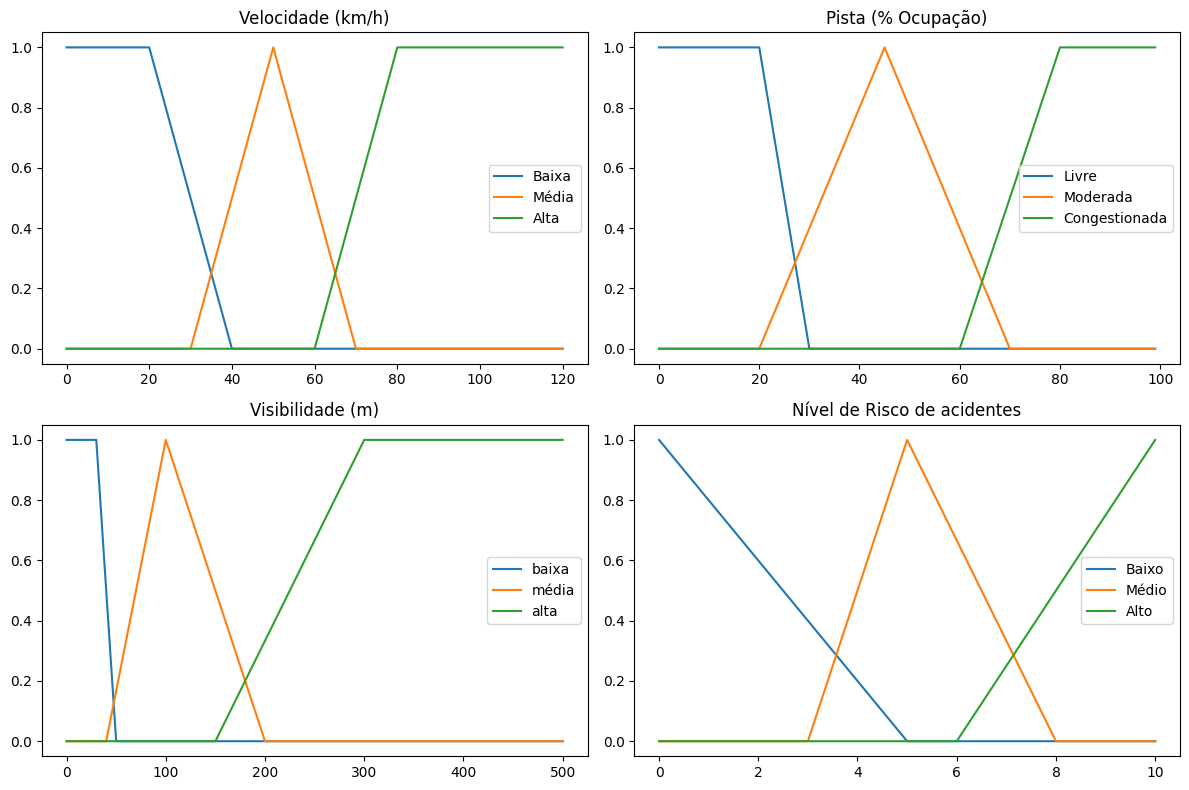

In [67]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
# Velocidade
axs[0, 0].plot(vel.universe, vel['baixa'].mf, label='Baixa')
axs[0, 0].plot(vel.universe, vel['media'].mf, label='Média')
axs[0, 0].plot(vel.universe, vel['alta'].mf, label='Alta')
axs[0, 0].set_title('Velocidade (km/h)')
axs[0, 0].legend()

# Pista
axs[0, 1].plot(pista.universe, pista['livre'].mf, label='Livre')
axs[0, 1].plot(pista.universe, pista['moderada'].mf, label='Moderada')
axs[0, 1].plot(pista.universe, pista['congestionada'].mf, label='Congestionada')
axs[0, 1].set_title('Pista (% Ocupação)')
axs[0, 1].legend()

# Visibilidade
axs[1, 0].plot(vsb.universe, vsb['baixa'].mf, label='baixa')
axs[1, 0].plot(vsb.universe, vsb['media'].mf, label='média')
axs[1, 0].plot(vsb.universe, vsb['alta'].mf, label='alta')
axs[1, 0].set_title('Visibilidade (m)')
axs[1, 0].legend()

# Risco
axs[1, 1].plot(risco.universe, risco['baixo'].mf, label='Baixo')
axs[1, 1].plot(risco.universe, risco['medio'].mf, label='Médio')
axs[1, 1].plot(risco.universe, risco['alto'].mf, label='Alto')
axs[1, 1].set_title('Nível de Risco de acidentes')
axs[1, 1].legend()

plt.tight_layout()
plt.show()
